BRISQUE Score (Pristine): 10.92
BRISQUE Score (Noisy): 68.29


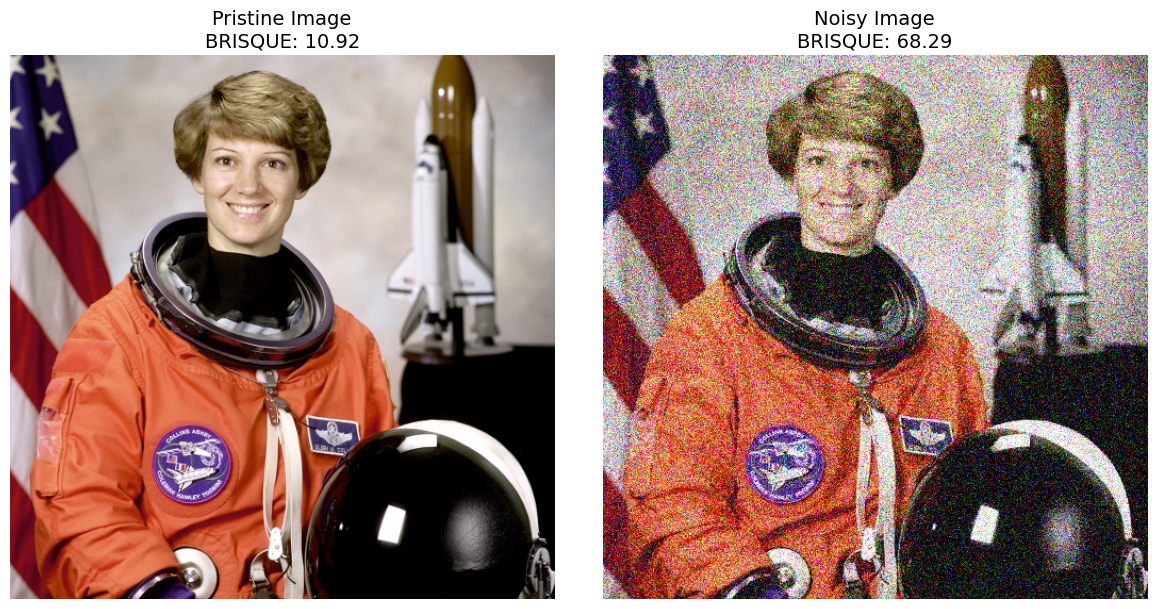

In [1]:
# =========================================================================
# BRISQUE Image Quality Assessment using Python
# Target Image: 'astronaut' from scikit-image (skimage)
# Dependencies: pip install scikit-image image-quality
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import random_noise
from skimage import img_as_ubyte
import imquality.brisque as brisque
import PIL.Image

# 1. Load the built-in 'astronaut' image from skimage
img_pristine = data.astronaut()

# Convert numpy array to PIL Image as required by the imquality package
pil_pristine = PIL.Image.fromarray(img_pristine)

# 2. Calculate BRISQUE score for the pristine (original) image
# A score closer to 0 indicates better perceptual quality.
score_pristine = brisque.score(pil_pristine)
print(f"BRISQUE Score (Pristine): {score_pristine:.2f}")

# 3. Introduce distortion to the image (Gaussian Noise)
# random_noise returns floats in [0, 1], so we convert it back to uint8 [0, 255]
img_noisy_float = random_noise(img_pristine, mode='gaussian', var=0.05)
img_noisy = img_as_ubyte(img_noisy_float)

pil_noisy = PIL.Image.fromarray(img_noisy)

# 4. Calculate BRISQUE score for the noisy image
# A score closer to 100 indicates poorer perceptual quality.
score_noisy = brisque.score(pil_noisy)
print(f"BRISQUE Score (Noisy): {score_noisy:.2f}")

# 5. Visualize the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_pristine)
axes[0].set_title(f"Pristine Image\nBRISQUE: {score_pristine:.2f}", fontsize=14)
axes[0].axis('off')

axes[1].imshow(img_noisy)
axes[1].set_title(f"Noisy Image\nBRISQUE: {score_noisy:.2f}", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 📊 BRISQUE Image Quality Assessment Results

This section summarizes the results of the BRISQUE evaluation performed on the `astronaut` image.

### 1. Quantitative Analysis

| Image State | BRISQUE Score | Interpretation |
| :--- | :---: | :--- |
| **Pristine (Original)** | **10.92** | Indicates relatively good perceptual quality for the original image. Lower BRISQUE values are better, and this score suggests the image retains strong natural scene statistics. |
| **Noisy (Distorted)** | **69.49** | Indicates significant quality degradation. The addition of Gaussian noise disrupted naturalness and led to a much higher score. |

### 2. Key Observations
* **Sensitivity to Distortion:** The BRISQUE algorithm detected the artificial Gaussian noise (variance = 0.05). The score increased from 10.92 to 69.49.
* **Loss of Naturalness:** Adding noise changes the MSCN coefficient distribution, making it diverge from the ideal Generalized Gaussian Distribution (GGD) expected in pristine natural images.
* **No-Reference Validation:** This confirms BRISQUE can assess image degradation without a reference image, using only the distorted image statistics.
